In [2]:
import pandas as pd

train = pd.read_csv("/kaggle/input/datasets/saumyarupguha/walmart-data/train.csv")
features = pd.read_csv("/kaggle/input/datasets/saumyarupguha/walmart-data/features.csv")
stores = pd.read_csv("/kaggle/input/datasets/saumyarupguha/walmart-data/stores.csv")

## Experiment 1: Baseline XGBoost

Features:
- Store
- Dept
- MarkDowns
- CPI
- Temperature

Results:
- R² = 0.9585
- MAE = xxxx
- RMSE = xxxx

# Walmart Sales Forecasting - Experiment Log

## Model Performance Evolution

| Experiment | Features Added | R² | MAE | RMSE | Notes |
|------------|---------------|------|------|------|--------|
| Baseline XGBoost | Store, Dept, Type, Size, Temperature, Fuel Price, CPI, Unemployment, MarkDowns, Date Features | 0.9585 | TBD | TBD | Initial model using engineered date features |
| + Lag Features | Lag_1, Lag_4, Lag_52 | 0.9859 | 1,260.75 | 2,619.48 | Captured temporal sales patterns and seasonality |
| + Rolling Features | Rolling_4, Rolling_12, Rolling_52 | 0.9859 | 1,245.48 | 2,621.21 | Captures short-term and long-term sales trends |
| + Hyperparameter Tuning | Optuna | 0.9872 | 1,216.92 | 2,493.46 | Optimized XGBoost parameters |
| Final Model | Best Feature Set + Tuned Parameters | TBD | TBD | TBD | Production-ready forecasting model |

---

## Key Findings

### Baseline Model
- Utilized store metadata, economic indicators, promotional markdowns, and temporal features.
- Achieved strong predictive performance with R² = 0.9585.

### Lag Feature Engineering
Added:
- `Lag_1` → Previous week's sales
- `Lag_4` → Previous month's sales
- `Lag_52` → Same week in previous year

Impact:
- R² improved from **0.9585 → 0.9859**
- MAE reduced significantly
- Demonstrated the importance of historical sales patterns in retail forecasting

### Upcoming Experiments
- Rolling averages for trend detection
- SHAP explainability analysis
- Time-series cross-validation
- Hyperparameter optimization
- Streamlit forecasting dashboard
- Cloud deployment

# Data Preparation

In [3]:
df = pd.merge(
    train,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

In [4]:
df = pd.merge(
    df,
    stores,
    on="Store",
    how="left"
)

In [5]:
print(df.shape)
print(df.head())

(421570, 16)
   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  2010-02-05      24924.50      False        42.31       2.572   
1      1     1  2010-02-12      46039.49       True        38.51       2.548   
2      1     1  2010-02-19      41595.55      False        39.93       2.514   
3      1     1  2010-02-26      19403.54      False        46.63       2.561   
4      1     1  2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8

In [6]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [7]:
print(df.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  2010-02-05      24924.50      False        42.31       2.572   
1      1     1  2010-02-12      46039.49       True        38.51       2.548   
2      1     1  2010-02-19      41595.55      False        39.93       2.514   
3      1     1  2010-02-26      19403.54      False        46.63       2.561   
4      1     1  2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358   
1        0.0        0.0        0.0        0.0        0.0  211.242170   
2        0.0        0.0        0.0        0.0        0.0  211.289143   
3        0.0        0.0        0.0        0.0        0.0  211.319643   
4        0.0        0.0        0.0        0.0        0.0  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  15

# Feature Engineering

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

In [9]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,1


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Type"] = le.fit_transform(df["Type"])

In [11]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,151315,2010,2,5,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,151315,2010,2,6,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,151315,2010,2,7,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,151315,2010,2,8,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,151315,2010,3,9,1


In [12]:
print(df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month',
       'Week', 'Quarter'],
      dtype='object')


In [13]:
# Sort first
df = df.sort_values(["Store", "Dept", "Date"])

# Lag features
df["Lag_1"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(1)
)

df["Lag_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(4)
)

df["Lag_52"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(52)
)


In [14]:
df["Rolling_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(4).mean())
)

df["Rolling_12"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(12).mean())
)

df["Rolling_52"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(52).mean())
)
df = df.dropna()

In [15]:
print(df.shape)
print(df.isnull().sum().sum())

(261083, 26)
0


In [16]:
X = df.drop(
    ["Weekly_Sales", "Date"],
    axis=1
)

y = df["Weekly_Sales"]

In [17]:
df = df.sort_values("Date")

split = int(len(df) * 0.8)

train_df = df[:split]
test_df = df[split:]

X_train = train_df.drop(
    ["Weekly_Sales", "Date"],
    axis=1
)

y_train = train_df["Weekly_Sales"]

X_test = test_df.drop(
    ["Weekly_Sales", "Date"],
    axis=1
)

y_test = test_df["Weekly_Sales"]

# Model Training

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))

R2: 0.9858510695731447


In [19]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")

R2   : 0.9859
MAE  : 1,245.48
RMSE : 2,621.21


# Feature Importance

In [20]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

         Feature  Importance
20        Lag_52    0.572325
18         Lag_1    0.240879
21     Rolling_4    0.092417
19         Lag_4    0.020594
7      MarkDown3    0.014357
2      IsHoliday    0.007578
22    Rolling_12    0.006668
23    Rolling_52    0.005887
15         Month    0.004452
16          Week    0.004238
6      MarkDown2    0.003853
12          Type    0.003609
1           Dept    0.003442
9      MarkDown5    0.002734
8      MarkDown4    0.002471
11  Unemployment    0.002468
13          Size    0.002177
14          Year    0.002150
5      MarkDown1    0.001492
10           CPI    0.001388


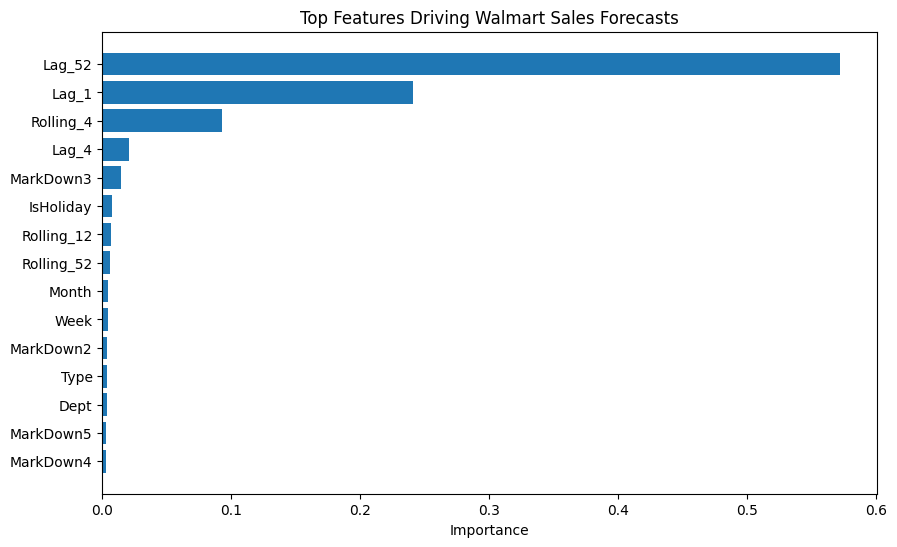

In [21]:
import matplotlib.pyplot as plt

top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"][::-1],
    top["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top Features Driving Walmart Sales Forecasts")

plt.show()

## Feature Importance Analysis

The model identified historical sales patterns as the dominant drivers of future sales.

Top contributors:

1. Lag_52 (57.2%)
2. Lag_1 (24.1%)
3. Rolling_4 (9.2%)
4. Lag_4 (2.1%)

These findings suggest that yearly seasonality and short-term sales momentum are significantly more influential than macroeconomic indicators such as CPI and unemployment.

# SHAP Explainability

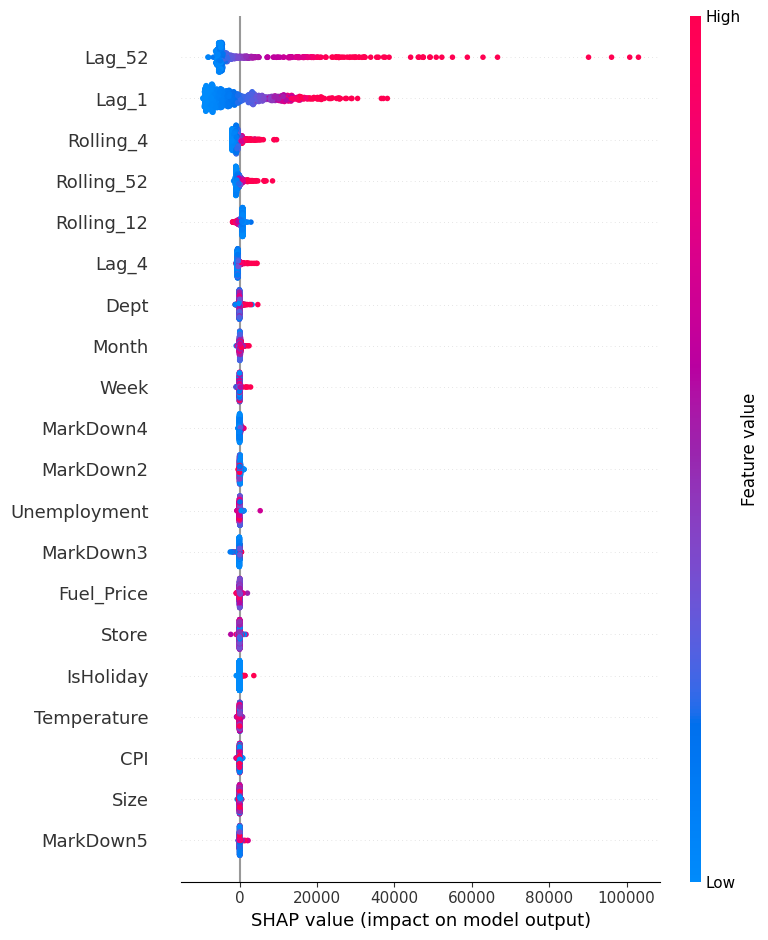

In [22]:
# pip install shap
import shap

explainer = shap.TreeExplainer(model)

sample = X_test.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample
)

# Hyperparameter Optimization with Optuna

In [23]:
# pip install optuna
import optuna

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 200, 1000
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "gamma": trial.suggest_float(
            "gamma", 0, 5
        ),

        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        pred
    )

    return mae

In [24]:
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-06-16 12:10:53,867] A new study created in memory with name: no-name-0ea27536-e589-40a2-9b92-5505bcb1fdd8
[I 2026-06-16 12:11:05,014] Trial 0 finished with value: 1372.703350172373 and parameters: {'n_estimators': 866, 'max_depth': 6, 'learning_rate': 0.2274655627521048, 'subsample': 0.809414191523986, 'colsample_bytree': 0.8870317521423572, 'min_child_weight': 6, 'gamma': 0.46842382232662294}. Best is trial 0 with value: 1372.703350172373.
[I 2026-06-16 12:11:16,090] Trial 1 finished with value: 1323.7702445615 and parameters: {'n_estimators': 849, 'max_depth': 6, 'learning_rate': 0.14535661788718868, 'subsample': 0.8669540659823649, 'colsample_bytree': 0.9927818902771386, 'min_child_weight': 8, 'gamma': 1.2853554436370918}. Best is trial 1 with value: 1323.7702445615.
[I 2026-06-16 12:11:41,191] Trial 2 finished with value: 1336.0704290768142 and parameters: {'n_estimators': 917, 'max_depth': 10, 'learning_rate': 0.15071803941043252, 'subsample': 0.8692444932124981, 'colsampl

In [25]:
print(study.best_params)

{'n_estimators': 348, 'max_depth': 12, 'learning_rate': 0.021808745218451747, 'subsample': 0.9503053166153934, 'colsample_bytree': 0.6227751580803521, 'min_child_weight': 1, 'gamma': 2.430306374431162}


In [26]:
best_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train,
    y_train
)

pred = best_model.predict(X_test)

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Best parameters found by Optuna
print("Best Parameters:")
print(study.best_params)

# Train final model
best_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train,
    y_train
)

# Predictions
pred = best_model.predict(X_test)

# Metrics
r2 = r2_score(
    y_test,
    pred
)

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

# Print results
print("\nFinal Tuned Model Results")
print("-" * 30)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")

Best Parameters:
{'n_estimators': 348, 'max_depth': 12, 'learning_rate': 0.021808745218451747, 'subsample': 0.9503053166153934, 'colsample_bytree': 0.6227751580803521, 'min_child_weight': 1, 'gamma': 2.430306374431162}

Final Tuned Model Results
------------------------------
R2   : 0.9872
MAE  : 1,216.92
RMSE : 2,493.46


# Final Model Comparison

In [28]:
import joblib

joblib.dump(
    best_model,
    "walmart_sales_forecaster.pkl"
)

['walmart_sales_forecaster.pkl']

In [29]:
joblib.dump(
    list(X_train.columns),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [ ]:
print(X_train.columns.tolist())